# Learning a Stream with an Autoencoder

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GalacticDynamics/phasecurvefit/blob/main/docs/tutorials/stream_autoencoder.ipynb)

A stellar stream is a thin trail of stars pulled off a globular cluster or dwarf
galaxy by the tides of its host galaxy. A catalogue gives each star's position and
velocity, but not *where along the stream* it sits. This tutorial recovers that
ordering, a coordinate $\gamma$ running from one tip of the stream to the other,
and a smooth mean track $\vec{x}(\gamma)$ through the stars.

It works in two stages:

1. **A local-flow walk** hops from star to star along the velocity field. It
   produces a reliable ordering, but only for a sparse subset of the stars.
2. **An autoencoder** learns from that subset to assign $\gamma$ to *every* star,
   and learns the mean track at the same time.

Along the way we look closely at the training loss curve, which is easy to
misread, and check which network weights the final model uses and whether they
are good ones.

This is the recommended first tutorial for streams. The
[running-mean tutorial](stream_runningmean.ipynb) swaps the learned track for a
faster, less accurate one, and the [MST tutorial](stream_mst.ipynb) orders the same
stream without choosing a starting star.

In [1]:
import dataclasses
import pathlib
import pickle

import galax.coordinates as gc
import galax.dynamics as gd
import galax.potential as gp
import jax
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import cKDTree

import quaxed.numpy as jnp
import unxt as u

import phasecurvefit as pcf

In [2]:
# One root random key; we split it whenever a step needs randomness.
key = jr.key(201030)

## Data: a simulated stream

We simulate a stream with [`galax`](https://github.com/GalacticDynamics/galax): a
$2.5 \times 10^4\,M_\odot$ cluster orbits for 4 Gyr in a flattened logarithmic
potential, and the Fardal et al. (2015) distribution function releases stars near
its Lagrange points. Stars released ahead of the cluster form the leading tail;
stars released behind it form the trailing tail.

The simulation takes a while, so the result is cached in `mockstream.pkl`; the cell
below loads it, and only re-runs the simulation if the file is missing.

In [3]:
usys = u.unitsystems.galactic

# Progenitor Parameters
prog_w0 = gc.PhaseSpaceCoordinate(
    q=u.Q([10, 3, 5], "kpc"), p=u.Q([-4, 100, 4], "km/s"), t=u.Q(0.0, "Myr")
)
prog_mass = u.Quantity(2.5e4, "Msun")

# Stream Distribution Function
df = gd.FardalStreamDF()

# Potential
pot = gp.LMJ09LogarithmicPotential(
    v_c=u.Q(150, "km/s"),
    r_s=u.Q(2, "kpc"),
    q1=1.0,
    q2=1.3,
    q3=0.9,
    phi=u.Q(0, "deg"),
    units=usys,
)

# Mock stream generator (galax)
mockgen = gd.MockStreamGenerator(df, pot)

In [4]:
mockstream_path = pathlib.Path("mockstream.pkl")
mockstream_path.parent.mkdir(parents=True, exist_ok=True)

try:
    if mockstream_path.exists():
        with mockstream_path.open("rb") as handle:
            mockstream, prog = pickle.load(handle)  # noqa: S301
    else:
        raise FileNotFoundError(f"Missing {mockstream_path}")  # noqa: EM102, TRY003, TRY301
except Exception as exc:  # noqa: BLE001
    print(f"Loading failed ({exc!r}); running the simulation.")
    mockstream, prog = mockgen.run(
        key,
        u.Q(jnp.linspace(0, 4, 4_000), "Gyr"),
        prog_w0,
        prog_mass,
    )
    mockstream = jax.block_until_ready(mockstream)
    with mockstream_path.open("wb") as handle:
        pickle.dump((mockstream, prog), handle)

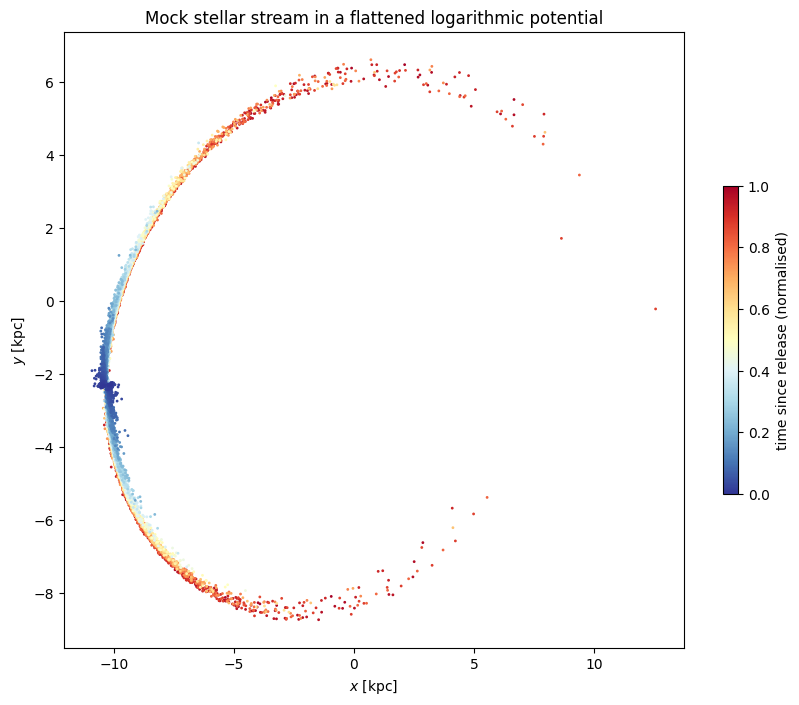

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.scatter(
    np.array(mockstream.q.x),
    np.array(mockstream.q.y),
    s=1,
    c=jnp.linspace(1, 0, len(mockstream.q)),
    cmap="RdYlBu_r",
)
fig.colorbar(im, ax=ax, label="time since release (normalised)", shrink=0.5)
ax.set(
    xlabel=r"$x$ [kpc]",
    ylabel=r"$y$ [kpc]",
    title="Mock stellar stream in a flattened logarithmic potential",
)
plt.show()

The colour is each star's position in the simulation output, which follows
release time: red stars left the cluster early and have drifted to the tips, blue
stars left recently and still sit near the cluster at $(x, y) \approx (-10, -2)$
kpc. This is the ordering we want to recover, but none of the methods below get to
see it.

## Shuffling

A real catalogue lists stars in no particular order along the stream. We shuffle
the simulated stars so the array order carries no information the methods could
exploit by accident.

In [6]:
# Shuffle the data
key, subkey = jr.split(key)
order = jr.permutation(subkey, jnp.arange(len(mockstream.q.x)))

qs = {k: getattr(mockstream.q, k)[order] for k in mockstream.q.components}
ps = {k: getattr(mockstream.p, k)[order] for k in mockstream.p.components}

## Step 1: a sparse ordering from the local-flow walk

The walk starts at one star and repeatedly steps to the unvisited star that best
continues the stream. The settings below control what "best continues" means:

- **`start_idx`**: we start at the star closest to the progenitor. It has to be a
  plain Python `int` (not a JAX array), because the walk is compiled around it.
- **`direction="both"`**: stars stream *away* from the progenitor in both
  directions, so from the middle we walk forward along the velocities to one tip,
  then backward (velocities negated) to the other. The two halves are joined into
  a single ordering with $\gamma \in [-1, 1]$ and the progenitor near $\gamma = 0$.
- **`AlignedMomentumDistanceMetric`** scores a candidate as
  $d = d_0 + \lambda (1 - \cos\theta)$: its distance $d_0$ plus a penalty for
  lying off the current direction of motion ($\theta$ is the angle between the
  current velocity and the step). `metric_scale` sets $\lambda$. At 100 kpc,
  stepping even $15°$ off-axis costs more than a 3 kpc step straight ahead, so the
  walk strongly prefers to keep going the way the stream flows.
- **`KDTree(k=50)`**: at each step only the 50 nearest stars are scored, which
  keeps the walk fast.
- **`max_dist`**: the walk stops when its chosen step would be longer than 3 kpc.
  This is gap detection: it keeps the walk from leaping onto an unrelated part of
  the stream once it runs out of stars.

In [7]:
# The index of the star closest to the progenitor. It must be a Python int.
start_idx = int(np.argmin(jnp.linalg.norm(mockstream.q[order] - prog.q, axis=1)))

walk_config = pcf.WalkConfig(
    strategy=pcf.strats.KDTree(k=50),
    metric=pcf.metrics.AlignedMomentumDistanceMetric(),
)
walkresult = pcf.order(
    qs,
    ps,
    pcf.orderers.LocalFlowOrderer(
        start_idx=start_idx,
        metric_scale=u.Q(100, "kpc"),
        max_dist=u.Q(3, "kpc"),
        config=walk_config,
        direction="both",
    ),
    metadata=pcf.StateMetadata(usys=usys),
)

n_visited = int((walkresult.indices >= 0).sum())
print(f"gamma range: {walkresult.gamma_range}")
print(f"stars ordered by the walk: {n_visited} of {len(walkresult.indices)}")

gamma range: (-1.0, 1.0)
stars ordered by the walk: 248 of 8000


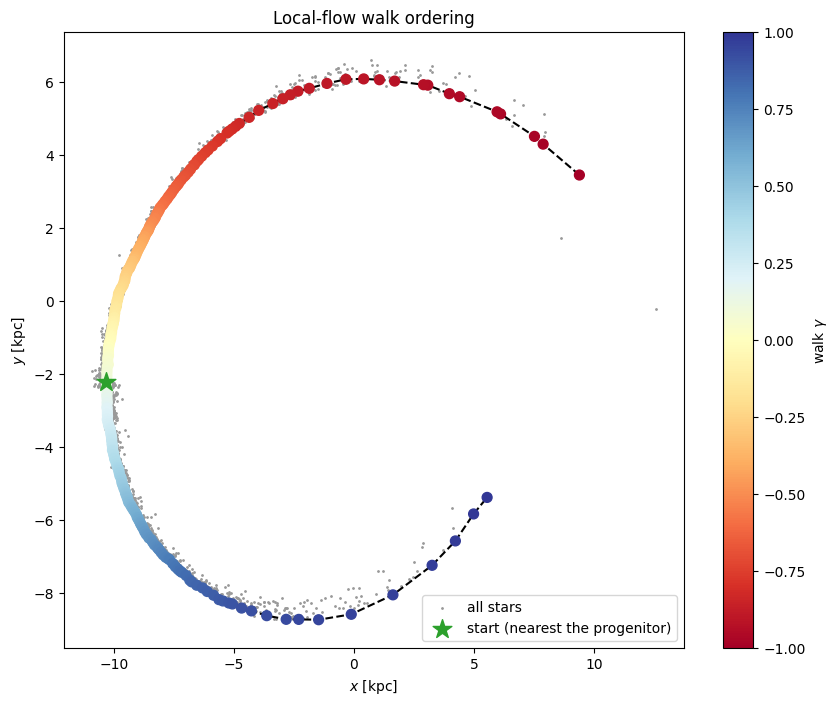

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(qs["x"], qs["y"], s=1, c="0.6", label="all stars")

ordering = walkresult.ordering
walk_qs = {k: v[ordering] for k, v in walkresult.positions.items()}
walk_gamma = np.linspace(*walkresult.gamma_range, len(ordering))
im = ax.scatter(walk_qs["x"], walk_qs["y"], s=50, c=walk_gamma, cmap="RdYlBu", zorder=3)
ax.plot(walk_qs["x"], walk_qs["y"], c="k", lw=1.5, ls="--", zorder=2)
ax.scatter(
    [qs["x"][start_idx]],
    [qs["y"][start_idx]],
    s=200,
    c="tab:green",
    marker="*",
    label="start (nearest the progenitor)",
    zorder=4,
)

fig.colorbar(im, ax=ax, label=r"walk $\gamma$")
ax.set(xlabel=r"$x$ [kpc]", ylabel=r"$y$ [kpc]", title="Local-flow walk ordering")
ax.legend()
plt.show()

**What to look for:** the dashed line should run from one tip, through the
starting star, to the other tip without jumping between the inner and outer edges
of the stream. It does.

Only about 3% of the stars are visited. That is by design: the walk follows a
single thread through the stream, one star per step, rather than sweeping up the
stars on either side of it. Where the stream is dense the steps are short; out at
the sparse tips they stretch to a few kpc. The result is a reliable *skeleton* of
the stream. Extending the ordering to all the stars is the autoencoder's job.

## Step 2: extending the ordering with an autoencoder

The `PathAutoencoder` has two networks:

- an **encoder**, $(\vec{x}, \vec{v}) \to (\gamma, p)$, that maps any star to an
  ordering coordinate $\gamma$ and a membership probability $p$, and
- a **decoder**, $\gamma \to \vec{x}$, that maps an ordering coordinate back to a
  position on the mean track.

Before either sees the data, a `StandardScalerNormalizer` rescales each coordinate
to zero mean and unit variance, so that positions in kpc and velocities in
kpc/Myr carry comparable weight. Results are converted back to physical units.

`train_autoencoder` trains in three phases, each with its own objective:

| Phase | Default epochs | Trains | Objective |
|---|---|---|---|
| 1. encoder | 800 | encoder | match the walk's $\gamma$ on the ordered stars; separate stream stars from random points ($p$) |
| 2. decoder | 100 | decoder (encoder frozen) | reproduce a running mean of the ordered stars' positions, as a warm start |
| 3. joint | 200 | both | put every member star close to the track at its own $\gamma$, *and* align the track's direction with the stars' velocities |

In phase 3 the weight on velocity alignment, $\lambda_p$, ramps linearly from 1 to
5. We keep the `TrainingConfig` in a variable so we can refer to the phase lengths
when reading the loss curve.

In [9]:
key, model_key, train_key = jr.split(key, 3)
normalizer = pcf.nn.StandardScalerNormalizer(qs, ps)
model = pcf.nn.PathAutoencoder.make(
    normalizer, gamma_range=walkresult.gamma_range, key=model_key
)

train_config = pcf.nn.TrainingConfig()  # the defaults, kept for reference below
result, opt_states, losses = pcf.nn.train_autoencoder(
    model, walkresult, config=train_config, key=train_key
)

Training:   0%|          | 0/800 [00:00<?, ?epoch/s]

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training:   0%|          | 0/200 [00:00<?, ?epoch/s]

## Reading the loss curve

`losses` holds one value per epoch, with the three phases concatenated. We shade
the phases so the curve can be read correctly.

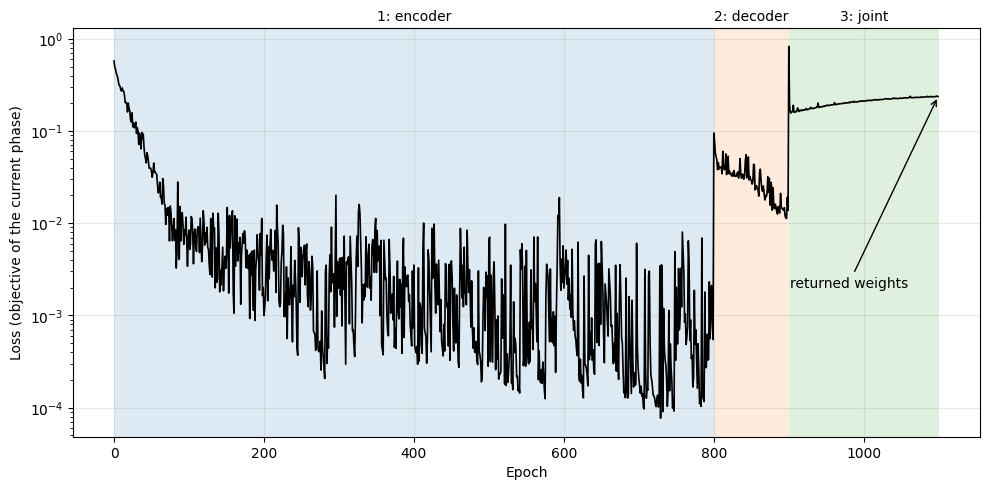

In [10]:
end_1 = train_config.n_epochs_encoder
end_2 = end_1 + train_config.n_epochs_decoder
end_3 = end_2 + train_config.n_epochs_both

fig, ax = plt.subplots(figsize=(10, 5))
phases = [
    (0, end_1, "1: encoder", "C0"),
    (end_1, end_2, "2: decoder", "C1"),
    (end_2, end_3, "3: joint", "C2"),
]
for lo, hi, name, color in phases:
    ax.axvspan(lo, hi, color=color, alpha=0.15, lw=0)
    ax.text(
        (lo + hi) / 2,
        1.01,
        name,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
    )
ax.plot(np.asarray(losses), c="k", lw=1.2)
ax.annotate(
    "returned weights",
    xy=(end_3 - 1, float(losses[-1])),
    xytext=(end_3 - 120, 2e-3),
    ha="center",
    arrowprops={"arrowstyle": "->"},
)
ax.set(xlabel="Epoch", ylabel="Loss (objective of the current phase)", yscale="log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Because each phase optimises a different objective, **loss values can only be
compared within a phase**, never across a boundary:

- **Phase 1** falls to about $10^{-4}$. This measures only how well the encoder
  reproduces the walk's ordering; no track exists yet.
- **The jump at the start of phase 2** is the loss switching to a different
  quantity (track error), computed by a freshly initialised decoder.
- **The jump at the start of phase 3** is another switch, to an objective that
  adds a velocity-alignment term.
- **The slow rise through phase 3** is the $\lambda_p$ ramp. The velocity term is
  weighted 5× more heavily at the end of the phase than at the start, so the same
  model error reports a larger loss. A rising curve here does not mean the model
  is getting worse.

**Which weights does the final model use?** Those from the last epoch of the last
phase, marked by the arrow. `train_autoencoder` does not keep a "best loss"
checkpoint, and picking the lowest point on this curve would be misleading: the
lowest values are in phase 1, before the decoder has been trained at all.

To judge the model we need a measure that means the same thing throughout, which
we check next.

## Checking the final weights

A measure that does not change between phases: how far each star lies from the
decoded track. We compute it for the final model and for the model as it stood at
the end of phase 2. Re-running training with `n_epochs_both=0` and the same keys
reproduces phases 1 and 2 exactly, so that second model is the same one the curve
above passes through at epoch 900.

In [11]:
def distance_to_track(result):
    """Distance (kpc) from each star to the nearest point on the decoded track."""
    track = result(jnp.linspace(*result.gamma_range, 5_000))
    comps = ("x", "y", "z")
    T = np.stack([np.asarray(u.ustrip("kpc", track[c])) for c in comps], axis=1)
    P = np.stack([np.asarray(u.ustrip("kpc", qs[c])) for c in comps], axis=1)
    return cKDTree(T).query(P)[0]


# The same training, stopped after phase 2.
config_12 = dataclasses.replace(train_config, n_epochs_both=0, show_pbar=False)
result_12, _, _ = pcf.nn.train_autoencoder(
    model, walkresult, config=config_12, key=train_key
)

print(f"{'model':<24}{'median [kpc]':>14}{'90th pct [kpc]':>16}")
for name, res in [("after phase 2", result_12), ("final (after phase 3)", result)]:
    d = distance_to_track(res)
    print(f"{name:<24}{np.median(d):>14.3f}{np.percentile(d, 90):>16.3f}")

model                     median [kpc]  90th pct [kpc]


after phase 2                    0.777           3.035
final (after phase 3)            0.068           0.156


The final weights are the better model by a wide margin, even though the loss
curve seemed to say otherwise. Phase 3 is where most of the improvement happens:
phase 2 only fits the track to the few hundred stars the walk ordered, while
phase 3 fits it to every star the encoder considers a member.

If on your data phase 3 makes the track worse by this kind of measure, set
`n_epochs_both=0` to stop after phase 2. The
[epitrochoid MST tutorial](epitrochoid_mst.ipynb) does this for a curve where the
joint phase does not help.

## Result

Finally, we colour every star by the $\gamma$ the encoder assigns it and draw the
mean track. Stars whose membership probability $p$ falls below the training
threshold (`train_config.member_threshold`, 0.5 by default) are circled in cyan:
the encoder does not consider them part of the stream.

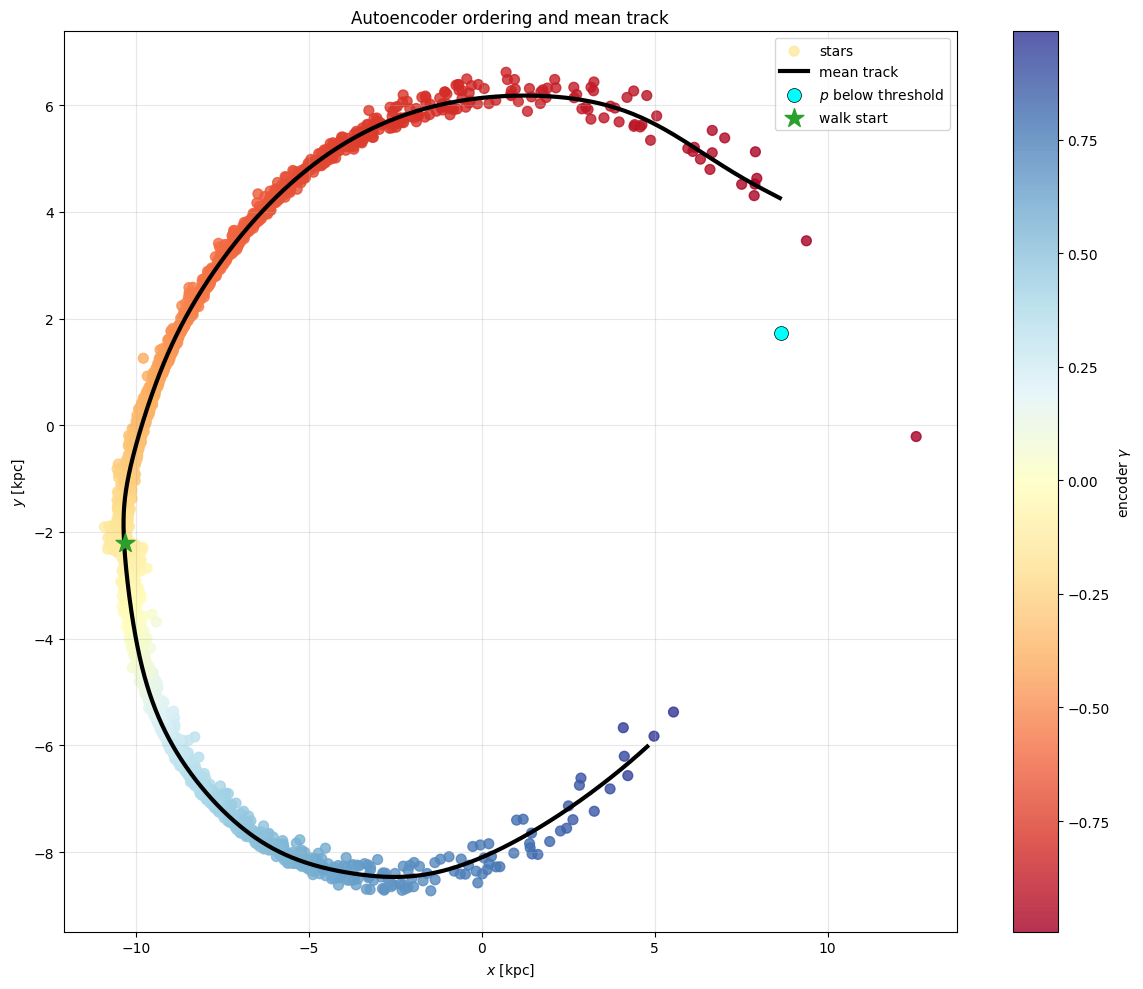

In [12]:
all_gamma, all_probs = result.model.encode(walkresult.positions, walkresult.velocities)
rejected = all_probs < train_config.member_threshold
track = result(jnp.linspace(*result.gamma_range, 1_000))

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.scatter(
    np.asarray(qs["x"]),
    np.asarray(qs["y"]),
    s=50,
    c=np.asarray(all_gamma),
    cmap="RdYlBu",
    alpha=0.8,
    label="stars",
)
ax.plot(np.asarray(track["x"]), np.asarray(track["y"]), c="k", lw=3, label="mean track")
ax.scatter(
    np.asarray(qs["x"][rejected]),
    np.asarray(qs["y"][rejected]),
    s=100,
    c="cyan",
    edgecolors="black",
    linewidths=0.5,
    label=r"$p$ below threshold",
)
ax.scatter(
    np.asarray(qs["x"][start_idx]),
    np.asarray(qs["y"][start_idx]),
    s=200,
    c="tab:green",
    marker="*",
    label="walk start",
    zorder=5,
)
fig.colorbar(im, ax=ax, label=r"encoder $\gamma$")
ax.set(
    xlabel=r"$x$ [kpc]",
    ylabel=r"$y$ [kpc]",
    title="Autoencoder ordering and mean track",
)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What to look for:** the colour now changes smoothly along the *whole*
stream, not just along the walk's few hundred stars, and the track runs down the
middle of the stream from tip to tip.

Notice that only one of the two far-flung stars on the right is flagged. The
encoder's $p$ is a simple classifier, trained to tell stream stars from random
points, and is not designed to reject contaminating field stars. For real outlier
rejection, see the [outlier rejection tutorial](outlier_rejection.ipynb).

## Takeaways

- The **walk** gives a sparse but reliable ordering; the **autoencoder** extends it
  to every star and learns a smooth mean track.
- The loss curve concatenates **three different objectives**. Compare values only
  within a phase, and judge the finished model with a fixed measure such as the
  distance from stars to the track.
- The returned model uses the **final-epoch weights**. Set `n_epochs_both=0` if the
  joint phase does not help on your data.

**Next:** the [running-mean tutorial](stream_runningmean.ipynb) trades accuracy for
speed, and the [MST tutorial](stream_mst.ipynb) orders this stream without a
starting star and rejects injected interlopers.